# Solve Model

## Hatano-Nelson model

10.1103/PhysRevX.13.021007

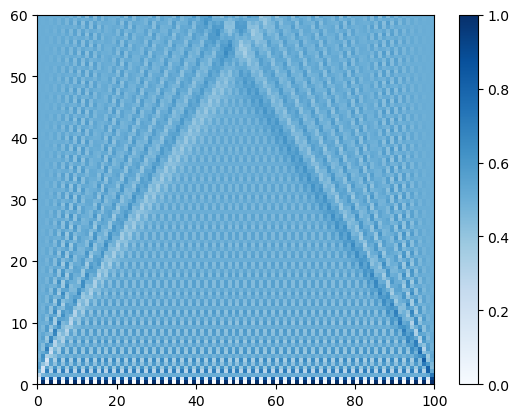

In [1]:
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import xx_evolve
res = xx_evolve(L, ham, "01"*(L//2), np.linspace(0, 60, 100))

import matplotlib.pyplot as plt
plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.colorbar()

other observables

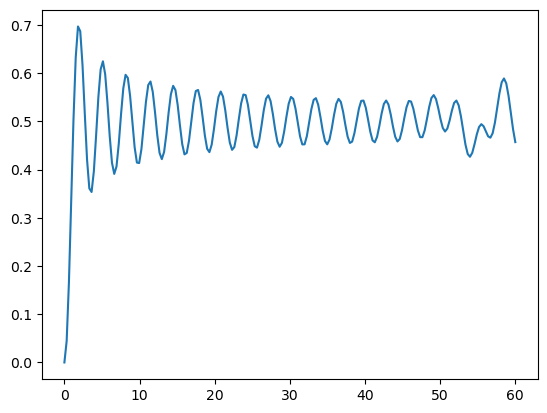

In [2]:
# particle number
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 200)
result = []
for s in state.evolve(h, tlist):
    result.append(s.particle_number(L//2))
res = np.array(result)

import matplotlib.pyplot as plt
plt.plot(tlist, res)

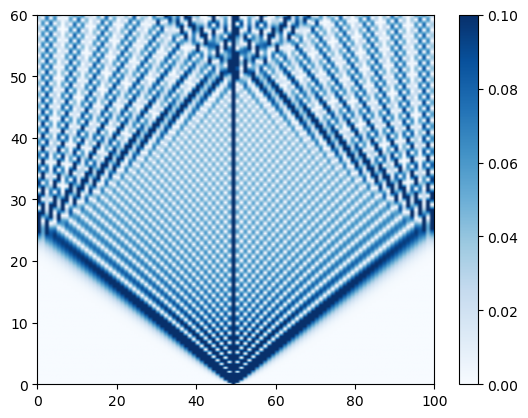

In [3]:
# correlation
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 500)
result = []
for s in state.evolve(h, tlist):
    result.append(s.correlation())  
    # default is the correlation w.r.t. the middle site
res = np.abs(result)

import matplotlib.pyplot as plt
plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.clim(0,0.1)
plt.colorbar()

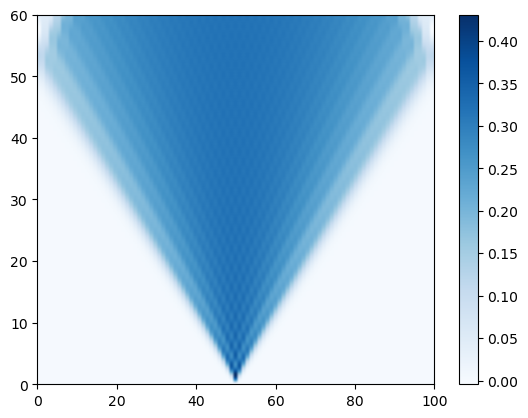

In [ ]:
# particle number current
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 500)
result = []
for s in state.evolve(h, tlist):
    obst = [np.imag(sum(s.U[l, :] * s.U[l+1, :].conj())) for l in range(L-1)]
    result.append(obst)
    # default is the correlation w.r.t. the middle site
res = np.array(result)

import matplotlib.pyplot as plt

plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.colorbar()

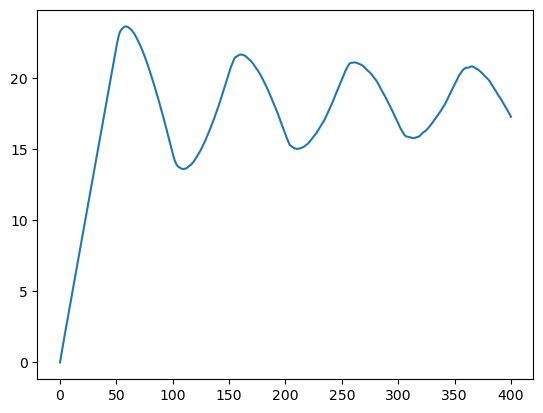

In [5]:
# entangement
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 400, 500)
result = []
for s in state.evolve(h, tlist):
    result.append(s.entanglement(range(L//2)))  
    # default is the correlation w.r.t. the middle site
res = np.array(result)

import matplotlib.pyplot as plt
plt.plot(tlist, res)

In [6]:
# reduced density matrix
import quante as qt
import numpy as np

op = qt.generate.operas

L = 100
J, γ = 1, 0.

builder = op.SpinBuilder()
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

model = ham.jw_transfer()
h = model.single_particle_ham(L)
state_str = "10"*(L//2) + "1"*(L%2)

from quante.solvable_models.gaussian_state import SlaterState
state = SlaterState.from_product_state(state_str, spin=True)
tlist = np.linspace(0, 60, 100)
result = []
s = state
for s in state.evolve(h, tlist):
    pass

s.reduced_density_matrix([50,51])

array([[0.25991372+0.j        , 0.        +0.j        , 0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.2831486 +0.j        , 0.        +0.03526381j, 0.        +0.j        ],
       [0.        +0.j        , 0.        -0.03526381j, 0.22098368-0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        , 0.        +0.j        , 0.235954  +0.j        ]])

In [7]:
# reduced density matrix —— banchmark
import quante as qt
import numpy as np

op = qt.generate.operas

L = 10
J, γ = 1, 0.

builder = op.SpinBuilder()
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

model = ham.jw_transfer()
h = model.single_particle_ham(L)
state_str = "10"*(L//2) + "1"*(L%2)

from quante.solvable_models.gaussian_state import SlaterState
state = SlaterState.from_product_state(state_str, spin=True)
tlist = np.linspace(0, 60, 100)
result = []
s = state
for s in state.evolve(h, tlist):
    pass

show(s.reduced_density_matrix([4,5]))

# now use ed
state = qt.generate.state.product_state(state_str)
basis = qt.generate.basis.spin_basis(L=L)
mat = ham.to_matrix(basis)
psi2 = qt.linalg.expm(mat, -1j*60) @ state

rhoA2 = qt.linalg.partial_trace(psi2, [2]*L, [4,5])
show(rhoA2)

s.reduced_density_matrix([4, 5]): 
   [[ 0.20951411+0.j          0.        +0.j          0.        +0.j          0.        +0.j        ]
    [ 0.        +0.j          0.1004162 +0.j         -0.        +0.06602575j  0.        +0.j        ]
    [ 0.        +0.j         -0.        -0.06602575j  0.48055557-0.j          0.        +0.j        ]
    [ 0.        +0.j          0.        +0.j          0.        +0.j          0.20951411+0.j        ]]
rhoA2: [[ 0.20951411+0.j          0.        +0.j          0.        -0.j         -0.        -0.j        ]
        [ 0.        -0.j          0.1004162 +0.j         -0.        +0.06602575j -0.        +0.j        ]
        [ 0.        +0.j         -0.        -0.06602575j  0.48055557+0.j         -0.        -0.j        ]
        [-0.        +0.j         -0.        -0.j         -0.        +0.j          0.20951411+0.j        ]]


## Ising Chain

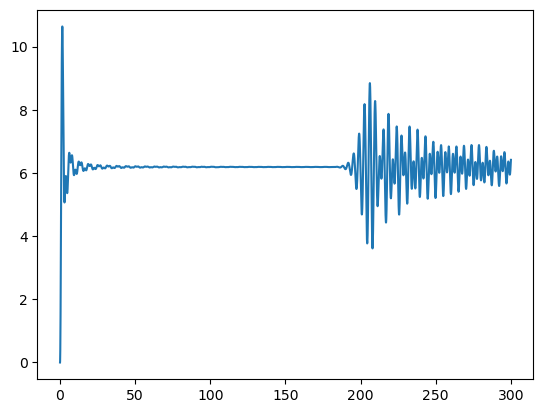

In [20]:
import quante as qt
import numpy as np
from quante.solvable_models import gaussian_state
L = 100
builder = qt.generate.operas.SpinBuilder()
for i in range(L-1):
    builder += "xx", [i+1, i], 1.
for i in range(L):
    builder += "z", [i], 1.
ham = builder.build()
tlist = np.linspace(0, 300, 10000)
result = gaussian_state.ising_evolve(
    L, ham, '0'*L, tlist
)
plt.plot(tlist, result)

## Spinful Fermion

10.1103/PhysRevX.13.021007

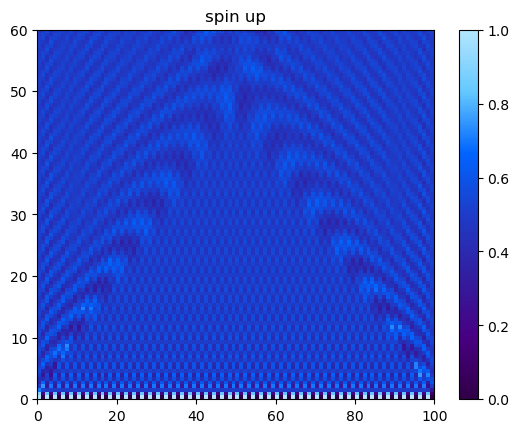

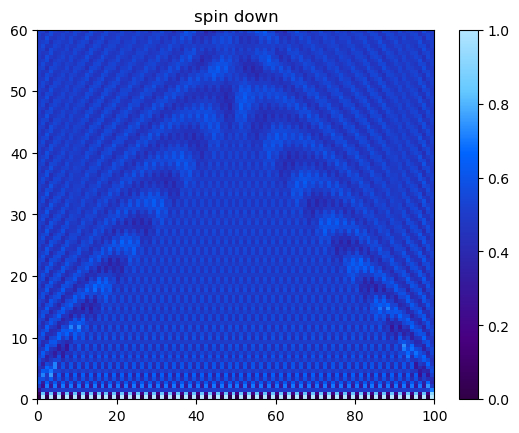

In [1]:
import quante as qt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
colors = [
    (48/255, 0/255, 70/255),   # 深紫色
    (72/255, 0/255, 130/255),  # 紫
    (50/255, 30/255, 160/255), # 紫蓝
    (30/255, 60/255, 200/255), # 深蓝
    (0/255, 100/255, 255/255), # 蓝色
    (100/255, 200/255, 255/255), # 淡蓝
    (180/255, 230/255, 255/255)  # 青色 / 浅青蓝
]
custom_cmap = LinearSegmentedColormap.from_list("smooth_purple_blue", colors, N=256)

slater = qt.solvable_models.gaussian_state.slater
op = qt.generate.operas.fermion

L = 100

J = 1.
γ = 0.
Δ = 0.5
builder = op.SpinfulFermionBuilder()
for l in range(L-1):
    # hopping term
    builder += '+-|', [l+1, l], -J/2
    builder += '|+-', [l+1, l], -J/2
    builder += '+-|', [l, l+1], -J/2
    builder += '|+-', [l, l+1], -J/2

    # non-hermitian term
    builder += '+-|', [l+1, l], -γ/2
    builder += '|+-', [l+1, l],  γ/2
    builder += '+-|', [l, l+1],  γ/2
    builder += '|+-', [l, l+1], -γ/2

    # spin-orbit coupling term
    builder += '+|-', [l+1, l], 1j * Δ/2
    builder += '-|+', [l+1, l], 1j * Δ/2
    builder += '-|+', [l, l+1], - 1j * Δ/2
    builder += '+|-', [l, l+1], - 1j * Δ/2
spinfulham = builder.build()


ham = spinfulham.to_spinless().normal_ordering()
h, coef_I = ham.single_particle_ham()
state = '10' * (L//2) + '|' + '01' * (L//2)
state = slater.SlaterState.from_spinful_product_state(state)
result2_spinup = []
result2_spindn = []
tlist = np.linspace(0, 0.6*L, 100)
for s in state.evolve(h, tlist):
    result2_spinup.append(s.particle_number(range(0,2*L,2)))
    result2_spindn.append(s.particle_number(range(1,2*L,2)))
result2_spinup = np.array(result2_spinup)
result2_spindn = np.array(result2_spindn)
plt.figure()
img = plt.imshow(result2_spinup, aspect='auto', extent=(0, L, 0, tlist[-1]), cmap=custom_cmap, origin='lower')  # 设置 
plt.title('spin up')
plt.colorbar(img)

plt.figure()
img = plt.imshow(result2_spindn, aspect='auto', extent=(0, L, 0, tlist[-1]), cmap=custom_cmap, origin='lower')  # 设置
plt.title('spin down')
plt.colorbar(img)
plt.show()

In [9]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

slater = qt.solvable_models.gaussian_state.slater
op = qt.generate.operas.fermion

L = 100
J = 1.
Δ = 0.5
plt.figure()
for γ in [0.5]:
    builder = op.SpinfulFermionBuilder()
    for l in range(L-1):
        # hopping term
        builder += '+-|', [l+1, l], -J/2
        builder += '|+-', [l+1, l], -J/2
        builder += '+-|', [l, l+1], -J/2
        builder += '|+-', [l, l+1], -J/2

        # non-hermitian term
        builder += '+-|', [l+1, l], -γ/2
        builder += '|+-', [l+1, l],  γ/2
        builder += '+-|', [l, l+1],  γ/2
        builder += '|+-', [l, l+1], -γ/2

        # spin-orbit coupling term
        builder += '+|-', [l+1, l], 1j * Δ/2
        builder += '-|+', [l+1, l], 1j * Δ/2
        builder += '-|+', [l, l+1], - 1j * Δ/2
        builder += '+|-', [l, l+1], - 1j * Δ/2
    spinfulham = builder.build()

    ham = spinfulham.to_spinless().normal_ordering()
    h, _ = ham.single_particle_ham()
    state = '10' * (L//2) + '|' + '01' * (L//2)
    state = slater.SlaterState.from_spinful_product_state(state)
    res = []
    tlist = np.linspace(0, 800, 16000)
    for s in state.evolve(h, tlist):
        res.append(s.entanglement(range(L)))
    res = np.array(res)
    plt.plot(tlist, res)
    plt.xlim(0,800)
    plt.ylim(0,50)

Evolving:  20%|#9        | 3169/16000 [00:29<01:58, 108.61step/s, dt=0.05]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>